<a href="https://colab.research.google.com/github/NairMpc/DataScience/blob/main/Assignment_13(2)_LGBM_XGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## XGBM and LGBM

### Introduction to XGBM and LGBM (for Diabetes Dataset Analysis)

In this assignment, two advanced ensemble learning techniques—XGBoost (XGBM) and LightGBM (LGBM)—will be utilized to build predictive models using the Diabetes dataset. Both algorithms are based on the concept of gradient boosting, where multiple weak learners (typically decision trees) are combined sequentially to improve overall model performance.

XGBoost (Extreme Gradient Boosting) is a highly efficient and scalable implementation of gradient boosting that incorporates regularization techniques to prevent overfitting and enhance generalization. It is known for its robustness, ability to handle missing values, and strong performance across a wide range of machine learning problems.

LightGBM (Light Gradient Boosting Machine), on the other hand, is designed to be faster and more memory-efficient than traditional boosting methods. It uses a leaf-wise tree growth strategy and histogram-based learning, which significantly reduces computation time while maintaining high accuracy, especially when working with large datasets.

In the context of the diabetes dataset, these algorithms will be applied to develop predictive models and evaluate their performance. The comparison between XGBoost and LightGBM will provide insights into their efficiency, accuracy, and suitability for structured medical data, thereby highlighting their practical significance in real-world predictive analytics.


###Introduction & Procedure (Diabetes Dataset – Model Building and Comparison)

Now, In the second phase of this assignment-13, predictive modeling will be performed using the Diabetes dataset. The objective will be to compare the performance of two advanced gradient boosting algorithms: LightGBM and XGBoost.

The process will begin by loading the dataset and examining its structure to understand the features and target variable. Since the dataset is expected to be primarily numerical, only minimal preprocessing will be required; however, necessary steps such as feature scaling or normalization will be applied if deemed beneficial.

Subsequently, the dataset will be split into training and testing sets to facilitate unbiased model evaluation. Suitable evaluation metrics, including accuracy, precision, recall, and F1-score, will be selected to assess model performance comprehensively.

Following this, predictive models will be developed using LightGBM and XGBoost. Both models will be trained on the training data and evaluated on the testing data. To further improve performance and robustness, techniques such as cross-validation and hyperparameter tuning will be implemented.

Finally, a comparative analysis will be conducted based on the evaluation metrics and visualizations. This will help in identifying the relative strengths and weaknesses of each algorithm and in determining their effectiveness for the given dataset.

### Building Predictive Models:( Use Diabetes dataset)
1.	Split the preprocessed dataset into training and testing sets.
2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.
3.	Build predictive models using LightGBM and XGBoost algorithms.
4.	Train the models on the training set and evaluate their performance on the testing set.
5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance.


### Dataset Selection Procedure

In this assignment, the objective is to build and evaluate a machine learning model using classification metrics such as Accuracy, Precision, Recall, and F1-score. These metrics are specifically designed for classification problems, where the target variable consists of discrete classes (e.g., Yes/No, 0/1).

However, commonly available datasets like the Diabetes Dataset (scikit-learn) from the scikit-learn library are regression datasets, where the target variable represents a continuous value. Since regression outputs are not categorical, applying classification metrics to such datasets would lead to incorrect or meaningless evaluation.

To address this mismatch, a suitable classification dataset is required. Therefore, we use the Pima Indians Diabetes Dataset, which is widely available on platforms like Kaggle and GitHub.

This dataset is appropriate because:

The target variable is binary (0 = Non-diabetic, 1 = Diabetic)
It aligns directly with classification tasks
It allows proper computation of Accuracy, Precision, Recall, and F1-score

Thus, selecting the Pima Indians Diabetes Dataset ensures that the evaluation metrics used in this assignment are both valid and meaningful.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Loading Pima Indians Diabetes Dataset
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

df = pd.read_csv(url)

display(df.head())


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


The dataset consists of a combination of clinical measurements and demographic attributes used to assess the likelihood of diabetes in patients.

The columns:

`Pregnancies` column indicates the number of times a patient has been pregnant, which may influence metabolic health.

`Glucose` column represents the plasma glucose concentration measured after a glucose tolerance test and is a key indicator of diabetes risk.

`BloodPressure` column refers to diastolic blood pressure, reflecting cardiovascular condition.

`SkinThickness` column measures subcutaneous fat, providing insight into body composition.

`Insulin` captures serum insulin levels, which are critical for understanding insulin resistance.

`BMI` (Body Mass Index) represents the ratio of weight to height and is strongly associated with obesity-related diabetes risk.

`DiabetesPedigreeFunction` quantifies the genetic predisposition to diabetes based on family history.

`Age` indicates the patient’s age, with higher values generally correlating with increased risk.

Finally, the `Outcome` column is the target variable, where 1 denotes a diabetic patient and 0 denotes a non-diabetic patient.

Basic info of data set

In [ ]:
print(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Based on the df.describe() output and general medical understanding, the following columns contain suspicious zero values:

Glucose: Minimum value is 0. A blood glucose level of 0 is physiologically impossible. This likely indicates a missing or unrecorded value.

BloodPressure: Minimum value is 0. A blood pressure reading of 0 is medically impossible. This also suggests missing data.

SkinThickness: Minimum value is 0. As discussed, a skin thickness of 0 is impossible. This is a common way to represent missing values in this dataset.

Insulin: Minimum value is 0. An insulin level of 0, while technically possible in very specific medical conditions, is often used as a placeholder for missing data in such datasets, especially when it appears frequently.

BMI: Minimum value is 0. A Body Mass Index (BMI) of 0 is impossible for a living human. This indicates missing data.

Pregnancies, DiabetesPedigreeFunction, and Age can legitimately have zero values, so they are left unchanged.

However, for Glucose, BloodPressure, SkinThickness, Insulin, and BMI, zero values are not realistic and are treated as missing data. These columns should be appropriately imputed during preprocessing.

In [ ]:
#Count the number of zero values in each suspicious column
suspicious_zeros_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in suspicious_zeros_cols:
    zero_count = (df[col] == 0).sum()
    print(f"Column '{col}': {zero_count} zero values")

Column 'Glucose': 5 zero values
Column 'BloodPressure': 35 zero values
Column 'SkinThickness': 227 zero values
Column 'Insulin': 374 zero values
Column 'BMI': 11 zero values


In [ ]:
# Replace zero values in suspicious columns with NaN
columns_to_replace_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[columns_to_replace_zeros] = df[columns_to_replace_zeros].replace(0, pd.NA)

print("Zero values replaced with NaN in the following columns:")
for col in columns_to_replace_zeros:
    nan_count = df[col].isna().sum()
    print(f"Column '{col}': {nan_count} NaN values")

Zero values replaced with NaN in the following columns:
Column 'Glucose': 5 NaN values
Column 'BloodPressure': 35 NaN values
Column 'SkinThickness': 227 NaN values
Column 'Insulin': 374 NaN values
Column 'BMI': 11 NaN values


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### Imputing Missing Values

Now that we've identified and marked the physiologically impossible zero values as `NaN`, we need to impute them. For numerical features, common imputation strategies include using the mean, median, or mode. Given that some distributions might be skewed, **median imputation** is a robust choice as it is less affected by outliers than mean imputation.

We will replace the `NaN` values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` with the median value of each respective column.

In [ ]:
columns_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_to_impute:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Column '{col}' imputed with median: {median_val}")

print("\nChecking for remaining NaN values after imputation:")
print(df[columns_to_impute].isnull().sum())

Column 'Glucose' imputed with median: 117.0
Column 'BloodPressure' imputed with median: 72.0
Column 'SkinThickness' imputed with median: 29.0
Column 'Insulin' imputed with median: 125.0
Column 'BMI' imputed with median: 32.3

Checking for remaining NaN values after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

### Class Distribution Analysis

In [ ]:
print("Class Distribution:")
print(y.value_counts())
print("\nPercentage Distribution:")
print(y.value_counts(normalize=True))

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentage Distribution:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


The dataset shows a slight class imbalance, where non-diabetic cases are more frequent than diabetic cases.
This justifies:

Use of stratified sampling

Importance of recall and F1-score over accuracy

### 1.Split the Dataset into Training and Testing Sets

Training set → used to train the model

Testing set → used only for final evaluation

Prevents data leakage

In [ ]:
from sklearn.model_selection import train_test_split

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

This split is done with an 80-20 ratio (test_size=0.2), uses a random_state=42 for reproducibility, and stratify=y to ensure that the proportion of 'Outcome' classes is maintained in both training and testing sets, which is particularly useful for imbalanced datasets

### 2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation

After splitting the dataset into training and testing sets, the next step is to define the evaluation criteria that will be used to assess model performance.

At this stage, no model has been trained yet, so no predictions are available. Therefore, evaluation metrics such as:

Accuracy,
Precision,
Recall,
F1-score

are selected in advance to ensure that the models are evaluated consistently and appropriately once predictions are generated.

In [ ]:
#Defining a re_uasable function for evaluation.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred):
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

The evaluate() function  allows for consistent evaluation of different models or hyperparameter settings once we trained a model.

Accuracy → overall correctness

It represents the proportion of total predictions that were correct (both true positives and true negatives) out of all the observations

Accuracy = (TP + TN) / (TP + FP + FN + TN)

Precision → correctness of positive predictions

 It tells us, out of all the instances the model predicted as positive (e.g., diabetic), how many were actually positive. Its formula is TP / (TP + FP)

Recall → ability to detect diabetic cases (very important)

 It tells us, out of all the instances that were actually positive, how many the model correctly identified as positive. Its formula is TP / (TP + FN).

F1-score → balance between precision & recall

F1-score = 2 * (Precision * Recall) / (Precision + Recall)

The F1-score is the harmonic mean of Precision and Recall, providing a single metric that balances both to evaluate a model's overall accuracy, especially useful in cases of imbalanced classes.



### 3. Build Predictive Models (LightGBM & XGBoost)

Both LightGBM and XGBoost use gradient boosting over decision trees:

Build many small decision trees sequentially

Each new tree corrects errors made by previous trees

Use gradients to minimize prediction error

Final prediction = sum of outputs from all trees

Difference:

LightGBM → grows trees leaf-wise (best-first split)
Expands the leaf with the highest error
Faster and more aggressive learning

XGBoost → grows trees level-wise (depth-wise split)
Expands all nodes at the same level evenly
More controlled and stable



In [ ]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Initialize models
lgb_model = LGBMClassifier(random_state=42, verbose=-1)
xgb_model = XGBClassifier(use_label_encoder=False,eval_metric='logloss', random_state=42)

### LightGBM (LGBMClassifier):
lgb_model = LGBMClassifier(

    random_state=42,          # overridden (default = None)
    n_estimators=100,         # default
    learning_rate=0.1,        # default
    num_leaves=31,            # default
    max_depth=-1,             # default (no limit)
    min_child_samples=20,     # default
    subsample=1.0,            # default
    colsample_bytree=1.0      # default
)

This code creates a baseline LightGBM model where:

Only random_state is explicitly overridden.
All other parameters remain at their default values.
The model behaves like a standard LightGBM configuration, with the added benefit of reproducible results due to the fixed random seed.

### XGBoost (XGBClassifier):
xgb_model = XGBClassifier(

    use_label_encoder=False,   # overridden (default = True in older versions)
    eval_metric='logloss',     # overridden (default chosen automatically)
    random_state=42,           # overridden (default = None)

    n_estimators=100,          # default
    learning_rate=0.1,         # default
    max_depth=6,               # default
    subsample=1.0,             # default
    colsample_bytree=1.0,      # default
    gamma=0,                   # default
    reg_lambda=1               # default
)

This initializes a baseline XGBoost model where:

Only three parameters are explicitly overridden.
All other hyperparameters remain at their default values.
The configuration ensures reproducibility, suppresses warnings, and uses a clearly defined evaluation metric, while keeping the model’s learning behavior standard.

### In short:
Baseline models are initialized using LightGBM and XGBoost classifiers with default parameters. The random_state parameter ensures reproducibility of results. In XGBoost, use_label_encoder=False is used to disable deprecated label encoding, and eval_metric='logloss' specifies the evaluation metric during training. These baseline models serve as a reference for further performance improvement through hyperparameter tuning.

### 4. Train Models & Evaluate on Test Set

Train on training data

Predict on test data

Evaluate performance

> This gives baseline results

In [ ]:
# Train models
lgb_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Predictions
lgb_pred = lgb_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

print("LightGBM Performance:")
evaluate(y_test, lgb_pred)

print("\nXGBoost Performance:")
evaluate(y_test, xgb_pred)

LightGBM Performance:
Accuracy : 0.7662337662337663
Precision: 0.68
Recall   : 0.6296296296296297
F1 Score : 0.6538461538461539

XGBoost Performance:
Accuracy : 0.7597402597402597
Precision: 0.673469387755102
Recall   : 0.6111111111111112
F1 Score : 0.6407766990291263


### Confusion Matrix (Baseline Models)
Purpose

To understand how many predictions are:

True Positives (correct diabetic)

True Negatives (correct non-diabetic)

False Positives (incorrect diabetic)

False Negatives (missed diabetic cases)

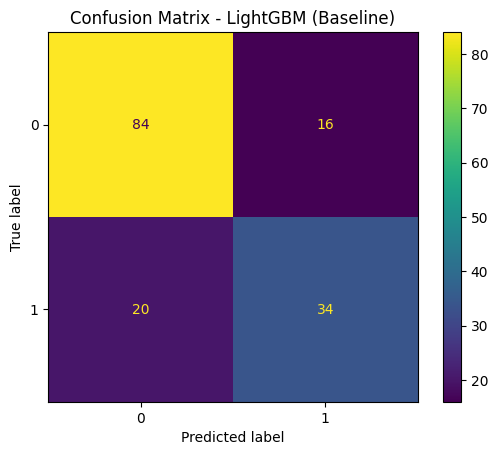

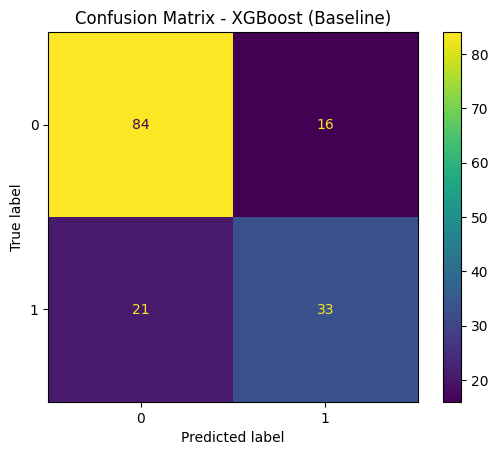

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# LightGBM Confusion Matrix
cm_lgb = confusion_matrix(y_test, lgb_pred)
ConfusionMatrixDisplay(cm_lgb).plot()
plt.title("Confusion Matrix - LightGBM (Baseline)")
plt.show()

# XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)
ConfusionMatrixDisplay(cm_xgb).plot()
plt.title("Confusion Matrix - XGBoost (Baseline)")
plt.show()

### Interpretation

The confusion matrix provides a detailed breakdown of prediction outcomes.
In medical diagnosis, false negatives are critical, as they represent diabetic patients incorrectly classified as healthy. A good model should minimize these cases while maintaining balanced performance.

### 5. Cross-Validation & Hyperparameter Tuning

This is where improvement happens:

**Cross-Validation

Split training data into folds (e.g., 5-fold)

Ensures model is stable

**Hyperparameter Tuning

Optimize parameters like:
learning_rate,
max_depth,
n_estimators

Done using GridSearchCV or RandomizedSearchCV

### Hyperparameter tuning (with CV inside)
GridSearchCV from scikit-learn is used to find the best combination of hyperparameters for a machine learning model by systematically trying multiple possibilities and evaluating them using cross-validation.

Tries every combination of those values

Evaluates each combination using cross-validation

Selects the best-performing set of parameters

cv=k refers to k-fold cross-validation, but the key idea is:

The dataset is split into k equal parts (folds)
The model is trained and validated k times

Each time:

k-1 folds → training
1 fold → validation (not “test”)

This rotates so every fold is used once as validation.



In [ ]:
#Define the parameter grid

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

In [ ]:
param_grid

{'n_estimators': [100, 200],
 'max_depth': [3, 5, 7],
 'learning_rate': [0.01, 0.1]}

In [ ]:
#LightGBM Grid Search

lgb_grid = GridSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

lgb_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LGBMClassifier(random_state=42, verbose=-1),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [ ]:
#XGBoost Grid Search

#from xgboost import XGBClassifier

xgb_grid = GridSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200]},
             scoring='f1')

### Comparative Analysis:
1.	Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.
2.	Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.


### Compare Results

In [ ]:
print("LightGBM Best Params:", lgb_grid.best_params_)
print("LightGBM Best F1:", lgb_grid.best_score_)

print("XGBoost Best Params:", xgb_grid.best_params_)
print("XGBoost Best F1:", xgb_grid.best_score_)

LightGBM Best Params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}
LightGBM Best F1: 0.6316765476033225
XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
XGBoost Best F1: 0.6194612030686902


LightGBM Best Params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}

LightGBM Best F1: 0.6316765476033225

XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

XGBoost Best F1: 0.6194612030686902

The hyperparameter tuning results show that LightGBM slightly outperforms XGBoost in terms of F1-score during cross-validation. LightGBM adopts a deeper and slower learning strategy, which enables it to capture more complex relationships in the dataset. In contrast, XGBoost uses a simpler and more regularized structure, which promotes stability and reduces the risk of overfitting. Although LightGBM demonstrates marginally better performance, the difference is not significant, and final conclusions should be based on evaluation using the test datase

To measure real-world performance using unseen data.

After hyperparameter tuning, the best models obtained from GridSearchCV are evaluated on unseen test data to measure real-world performance.

Take best_estimator_

Predict on X_test

Calculate metrics

In [ ]:
# Get best models
best_lgb = lgb_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

# Predictions
lgb_best_pred = best_lgb.predict(X_test)
xgb_best_pred = best_xgb.predict(X_test)

print("Tuned LightGBM Performance:")
evaluate(y_test, lgb_best_pred)

print("\nTuned XGBoost Performance:")
evaluate(y_test, xgb_best_pred)

Tuned LightGBM Performance:
Accuracy : 0.7532467532467533
Precision: 0.6666666666666666
Recall   : 0.5925925925925926
F1 Score : 0.6274509803921569

Tuned XGBoost Performance:
Accuracy : 0.7337662337662337
Precision: 0.6274509803921569
Recall   : 0.5925925925925926
F1 Score : 0.6095238095238096


### Confusion Matrix (Tuned Models)

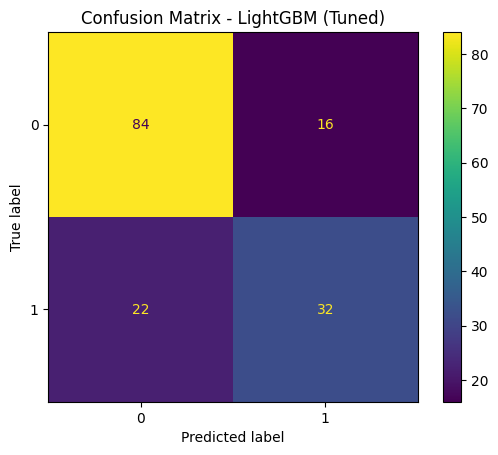

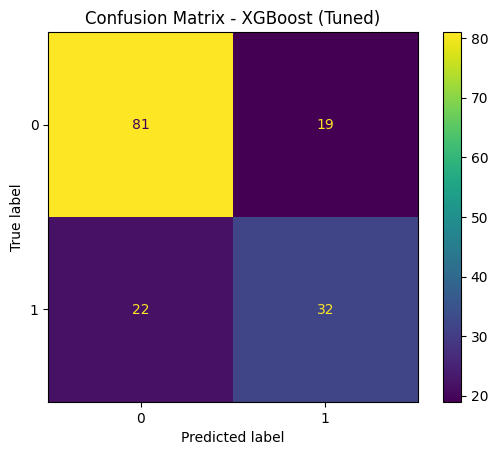

In [ ]:
# LightGBM Tuned
cm_lgb_best = confusion_matrix(y_test, lgb_best_pred)
ConfusionMatrixDisplay(cm_lgb_best).plot()
plt.title("Confusion Matrix - LightGBM (Tuned)")
plt.show()

# XGBoost Tuned
cm_xgb_best = confusion_matrix(y_test, xgb_best_pred)
ConfusionMatrixDisplay(cm_xgb_best).plot()
plt.title("Confusion Matrix - XGBoost (Tuned)")
plt.show()

### Interpretation

Let's compare the confusion matrices for both models before and after tuning:

LightGBM (Baseline vs. Tuned):

Baseline:

True Negatives (correctly identified non-diabetic): 84

False Positives (incorrectly identified as diabetic): 16

False Negatives (missed diabetic cases): 20

True Positives (correctly identified diabetic): 34

Tuned:

True Negatives: 84

False Positives: 16

False Negatives: 22

True Positives: 32

For LightGBM, after tuning, the number of True Positives decreased from 34 to 32, and the number of False Negatives increased from 20 to 22. The True Negatives and False Positives remained the same. This indicates that tuning, in this case, slightly worsened the model's ability to correctly identify diabetic patients, which is critical in this context.

XGBoost (Baseline vs. Tuned):

Baseline:

True Negatives: 84

False Positives: 16

False Negatives: 21

True Positives: 33

Tuned:

True Negatives: 81

False Positives: 19

False Negatives: 22

True Positives: 32

For XGBoost, after tuning, the model's performance generally declined across the board. True Negatives decreased (from 84 to 81), False Positives increased (from 16 to 19), False Negatives increased (from 21 to 22), and True Positives decreased (from 33 to 32).

Conclusion: Based on the confusion matrices, neither LightGBM nor XGBoost models showed improvement after cross-validation and tuning. In both cases, the tuned models resulted in an increase in false negatives and a decrease in true positives, which is not desirable, especially for a diabetes prediction task where missing a positive case (false negative) has significant implications. This is also reflected in the F1-score which dropped slightly for both models after tuning, as shown in the comparison table at the end of the notebook.



###To clearly compare models, performance metrics are organized into a structured table.

In [ ]:
import pandas as pd

# Store results
results = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lgb_best_pred),
        accuracy_score(y_test, xgb_best_pred)
    ],
    'Precision': [
        precision_score(y_test, lgb_best_pred),
        precision_score(y_test, xgb_best_pred)
    ],
    'Recall': [
        recall_score(y_test, lgb_best_pred),
        recall_score(y_test, xgb_best_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lgb_best_pred),
        f1_score(y_test, xgb_best_pred)
    ]
})

print(results)

      Model  Accuracy  Precision    Recall  F1 Score
0  LightGBM  0.753247   0.666667  0.592593  0.627451
1   XGBoost  0.733766   0.627451  0.592593  0.609524


### Visualization helps in better understanding model performance differences.

In [ ]:

results.set_index('Model')

,Accuracy,Precision,Recall,F1 Score
Model,,,,
LightGBM,0.753247,0.666667,0.592593,0.627451
XGBoost,0.733766,0.627451,0.592593,0.609524


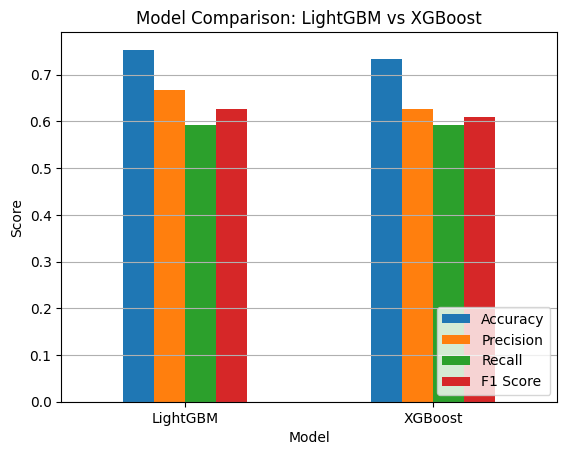

In [ ]:
import matplotlib.pyplot as plt

results.set_index('Model').plot(kind='bar')

plt.title("Model Comparison: LightGBM vs XGBoost")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y')

plt.show()

### Comparative Analysis

The comparative evaluation of LightGBM and XGBoost models on the test dataset reveals that both algorithms perform effectively in predicting diabetes, with only marginal differences in performance. LightGBM achieves higher accuracy (0.753), precision (0.667), and F1-score (0.627) compared to XGBoost, which records slightly lower values across these metrics. Notably, both models exhibit identical recall (0.593), indicating that they are equally capable of identifying diabetic patients.

The higher precision of LightGBM suggests that it produces fewer false positive predictions, making it more reliable when predicting positive cases. Additionally, the improved F1-score indicates a better balance between precision and recall.
#### These results demonstrate that LightGBM slightly outperforms XGBoost in terms of overall predictive performance.

However, the performance gap between the two models is relatively small, indicating that both algorithms are robust and suitable for this classification task. From a practical perspective, especially in healthcare applications where detecting true positive cases is critical, both models perform similarly in terms of recall. Therefore, the choice between the two may depend on secondary factors such as computational efficiency and ease of tuning.

### ROC Curve and AUC Score
The ROC curve (Receiver Operating Characteristic curve) is a graph showing the performance of a classification model at all classification thresholds. It plots two parameters:

True Positive Rate (TPR): Also known as Sensitivity or Recall, it's the proportion of actual positives that are correctly identified as such.
False Positive Rate (FPR): The proportion of actual negatives that are incorrectly identified as positive. It's calculated as 1 - Specificity.



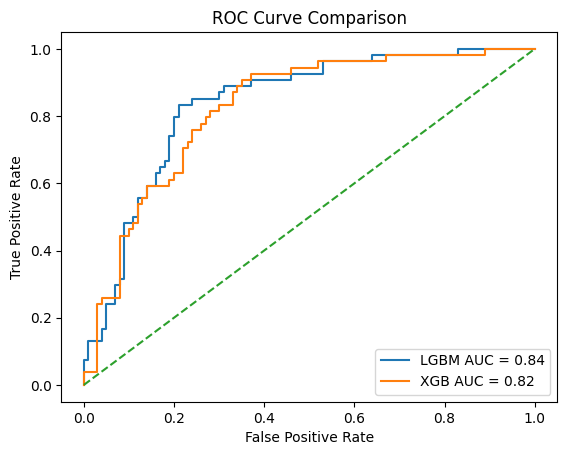

In [ ]:
from sklearn.metrics import roc_curve, auc

# LightGBM
lgb_probs = best_lgb.predict_proba(X_test)[:,1]
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_probs)
auc_lgb = auc(fpr_lgb, tpr_lgb)

# XGBoost
xgb_probs = best_xgb.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot
plt.plot(fpr_lgb, tpr_lgb, label=f"LGBM AUC = {auc_lgb:.2f}")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB AUC = {auc_xgb:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### Interpretation
LightGBM has a slightly higher AUC (0.84) compared to XGBoost (0.82), suggesting that LightGBM is marginally better at discriminating between the positive and negative classes across various thresholds. This aligns with the F1-score comparison where LightGBM also showed a slight edge. The curves are also relatively close to the top-left corner, indicating a good trade-off between sensitivity and specificity.


### Feature Importance Analysis

To identify which features contribute most to diabetes prediction.

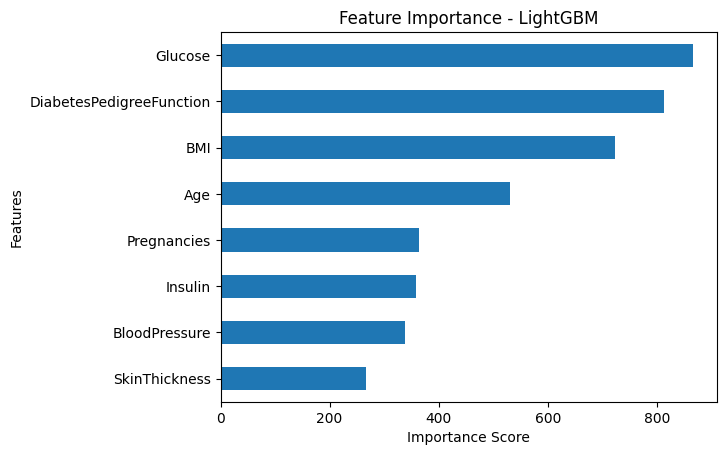

In [ ]:

# LightGBM Feature Importance
feat_imp = pd.Series(best_lgb.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance - LightGBM")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

#### we can see that:

Glucose has the highest importance score (866), making it the most influential feature in predicting diabetes.

DiabetesPedigreeFunction (813) and BMI (724) are also highly important, followed by Age (531).

Pregnancies (364), Insulin (359), BloodPressure (339), and SkinThickness (266) have comparatively lower but still significant importance.

This analysis helps us understand which medical measurements are most critical for diabetes prediction according to this LightGBM model, aligning with general medical understanding where glucose levels, BMI, and family history are key indicators.


### Final Conclusion

The comparative analysis demonstrates that both LightGBM and XGBoost perform effectively for diabetes prediction. LightGBM shows slightly better performance in terms of accuracy, precision, and F1-score, making it a more reliable model for this dataset.

However, both models exhibit similar recall, indicating comparable ability in identifying diabetic patients. Since recall is critical in healthcare applications, both models are suitable for this task.

Overall, LightGBM is preferred due to its slightly superior performance and efficiency, though the difference between the models remains marginal.